# SMHI Meteorological Stations Data Exploration

This notebook provides comprehensive analysis of the SMHI meteorological station data.

**Data Source**: 15 SMHI stations with both snow depth AND meteorological parameters

**Parameters**:
- `snow` - Snow depth (m)
- `wind` - Wind speed (m/s)
- `humidity` - Relative humidity (%)
- `pressure` - Sea-level pressure (hPa)
- `dew_point` - Dew point temperature (°C)
- `cloud_cover` - Total cloud cover (%)
- `precip` - Precipitation (mm)
- `ground_state` - Ground state code

In [ ]:
# # STEP 1: Fix pandas installation if needed
# # If pandas import fails, this cell will reinstall it
# # IMPORTANT: After reinstallation, you MUST restart the kernel manually:
# #   - Go to: Kernel → Restart Kernel
# #   - Then run all cells from the beginning

# import sys
# import subprocess

# try:
#     import pandas as pd
#     print(f"✓ Pandas {pd.__version__} is working correctly!")
#     print("You can proceed to the next cell.")
# except (AttributeError, ImportError) as e:
#     if '_pandas_datetime_CAPI' in str(e) or 'partially initialized' in str(e):
#         print("❌ Pandas installation is corrupted.")
#         print("\n🔧 Attempting to fix by reinstalling pandas...")
        
#         try:
#             # Reinstall pandas
#             result = subprocess.run(
#                 [sys.executable, "-m", "pip", "install", "--upgrade", "--force-reinstall", "--no-cache-dir", "pandas>=2.0.0"],
#                 capture_output=True,
#                 text=True,
#                 timeout=300
#             )
            
#             if result.returncode == 0:
#                 print("✓ Pandas reinstalled successfully!")
#                 print("\n⚠️  IMPORTANT: You MUST restart the kernel now:")
#                 print("   1. Go to: Kernel → Restart Kernel")
#                 print("   2. Then run all cells from the beginning")
#                 print("\n   Or use keyboard shortcut: Press '0' twice (00) in command mode")
#             else:
#                 print("✗ Reinstallation failed. Error:")
#                 print(result.stderr)
#                 print("\nPlease run manually in a new cell:")
#                 print("  !pip install --upgrade --force-reinstall pandas")
#         except Exception as ex:
#             print(f"✗ Could not reinstall automatically: {ex}")
#             print("\nPlease run manually in a new cell:")
#             print("  !pip install --upgrade --force-reinstall pandas")
#             print("\nThen restart the kernel and run cells again.")
#     else:
#         print(f"✗ Unexpected error: {e}")
#         raise

✓ Pandas 2.3.3 is working correctly!
You can proceed to the next cell.


In [1]:
# STEP 2: Import all libraries
# This cell imports all required libraries for the notebook

# try:
#     import pandas as pd
#     print(f"✓ Pandas {pd.__version__} loaded successfully")
# except (AttributeError, ImportError) as e:
#     if '_pandas_datetime_CAPI' in str(e) or 'partially initialized' in str(e):
#         print("❌ ERROR: Pandas is still corrupted.")
#         print("\nThis usually means:")
#         print("  1. Pandas was reinstalled but kernel wasn't restarted")
#         print("  2. Or pandas installation failed")
#         print("\nSOLUTION:")
#         print("  1. Restart the kernel: Kernel → Restart Kernel")
#         print("  2. Run cell 1 (the fix cell) again")
#         print("  3. If it reinstalls pandas, restart kernel again")
#         print("  4. Then run all cells from the beginning")
#         print("\nOr run in terminal (if you have access):")
#         print("  pip install --upgrade --force-reinstall pandas")
#         raise
#     else:
#         raise

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display and plot options
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palette for stations
COLORS = plt.cm.tab20(np.linspace(0, 1, 15))

print("✓ All libraries loaded successfully!")

✓ All libraries loaded successfully!


---
## 1. Data Loading and Initial Overview

In [2]:
# Load the data
df = pd.read_csv('../data/raw/smhi_metro.csv', parse_dates=['date'])

# Basic info
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Date Range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Duration: {(df['date'].max() - df['date'].min()).days} days")
print(f"Stations: {df['station_name'].nunique()}")

DATASET OVERVIEW
Shape: 44,981 rows x 17 columns
Memory: 9.13 MB
Date Range: 2015-01-01 to 2023-12-31
Duration: 3286 days
Stations: 15


In [3]:
# Display first and last rows
print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())


First 5 rows:


,date,station_id,station_name,latitude,longitude,elevation,snow,temp,temp_min,temp_max,precip,wind,humidity,pressure,dew_point,cloud_cover,ground_state
0,2018-10-16,188790,Abisko Aut,68.354,18.816,392.240,NaN,NaN,NaN,NaN,NaN,2.593,NaN,NaN,0.493,NaN,NaN
1,2018-10-17,188790,Abisko Aut,68.354,18.816,392.240,NaN,NaN,NaN,NaN,NaN,1.992,NaN,NaN,-0.017,NaN,NaN
2,2018-10-18,188790,Abisko Aut,68.354,18.816,392.240,NaN,NaN,NaN,NaN,NaN,3.750,NaN,NaN,0.050,NaN,NaN
3,2018-10-19,188790,Abisko Aut,68.354,18.816,392.240,NaN,NaN,NaN,NaN,NaN,4.667,NaN,NaN,1.446,NaN,NaN
4,2018-10-20,188790,Abisko Aut,68.354,18.816,392.240,NaN,NaN,NaN,NaN,NaN,2.117,NaN,NaN,0.979,NaN,NaN



Last 5 rows:


,date,station_id,station_name,latitude,longitude,elevation,snow,temp,temp_min,temp_max,precip,wind,humidity,pressure,dew_point,cloud_cover,ground_state
44976,2023-12-27,160960,Vidsel,65.873,20.148,180.060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.000
44977,2023-12-28,160960,Vidsel,65.873,20.148,180.060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.000
44978,2023-12-29,160960,Vidsel,65.873,20.148,180.060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.000
44979,2023-12-30,160960,Vidsel,65.873,20.148,180.060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.000
44980,2023-12-31,160960,Vidsel,65.873,20.148,180.060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.000


In [4]:
# Column info
print("\nColumn Data Types:")
print(df.dtypes)

print("\n" + "=" * 70)
print("COLUMNS DESCRIPTION")
print("=" * 70)
col_desc = {
    'date': 'Date of observation',
    'station_id': 'SMHI station identifier',
    'station_name': 'Station name',
    'latitude': 'Station latitude (°N)',
    'longitude': 'Station longitude (°E)',
    'elevation': 'Station elevation (m)',
    'snow': 'Snow depth (m)',
    'temp': 'Daily mean temperature (°C)',
    'temp_min': 'Daily minimum temperature (°C)',
    'temp_max': 'Daily maximum temperature (°C)',
    'precip': 'Daily precipitation (mm)',
    'wind': 'Mean wind speed (m/s)',
    'humidity': 'Relative humidity (%)',
    'pressure': 'Sea-level pressure (hPa)',
    'dew_point': 'Dew point temperature (°C)',
    'cloud_cover': 'Total cloud cover (0-8 oktas or %)',
    'ground_state': 'Ground state code'
}

for col in df.columns:
    print(f"{col:20} : {col_desc.get(col, 'Unknown')}")


Column Data Types:
date            datetime64[ns]
station_id               int64
station_name            object
latitude               float64
longitude              float64
elevation              float64
snow                   float64
temp                   float64
temp_min               float64
temp_max               float64
precip                 float64
wind                   float64
humidity               float64
pressure               float64
dew_point              float64
cloud_cover            float64
ground_state           float64
dtype: object

COLUMNS DESCRIPTION
date                 : Date of observation
station_id           : SMHI station identifier
station_name         : Station name
latitude             : Station latitude (°N)
longitude            : Station longitude (°E)
elevation            : Station elevation (m)
snow                 : Snow depth (m)
temp                 : Daily mean temperature (°C)
temp_min             : Daily minimum temperature (°C)
temp_max     

---
## 2. Station Information

In [5]:
# Station details
stations = df.groupby(['station_id', 'station_name', 'latitude', 'longitude', 'elevation']).agg({
    'date': ['min', 'max', 'count']
}).reset_index()
stations.columns = ['ID', 'Name', 'Lat', 'Lon', 'Elev', 'First', 'Last', 'Records']
stations = stations.sort_values('Lat', ascending=False)

print("=" * 90)
print("STATION DETAILS (sorted by latitude, north to south)")
print("=" * 90)
display(stations)

STATION DETAILS (sorted by latitude, north to south)


,ID,Name,Lat,Lon,Elev,First,Last,Records
13,188820,Katterjåkk,68.421,18.167,513.910,2015-01-01,2023-12-31,2911
14,188850,Katterjåkk A,68.420,18.168,514.250,2015-01-01,2023-12-31,3287
12,188790,Abisko Aut,68.354,18.816,392.240,2018-10-16,2023-12-31,1903
11,167710,Arjeplog A,66.051,17.840,430.840,2015-01-01,2023-12-31,3273
9,160960,Vidsel,65.873,20.148,180.060,2015-01-01,2023-12-31,3253
10,162860,Luleå-Kallax Flygplats,65.543,22.124,19.900,2015-01-01,2023-12-31,3287
6,97510,Uppsala Aut,59.847,17.632,23.540,2015-01-01,2023-12-31,3287
5,97380,Enköping,59.641,17.066,14.310,2015-01-07,2023-12-31,1592
8,99270,Svenska Högarna,59.444,19.503,10.140,2015-01-01,2021-12-31,2557
7,98210,Stockholm-Observatoriekullen,59.342,18.055,43.130,2015-01-01,2023-12-31,3287


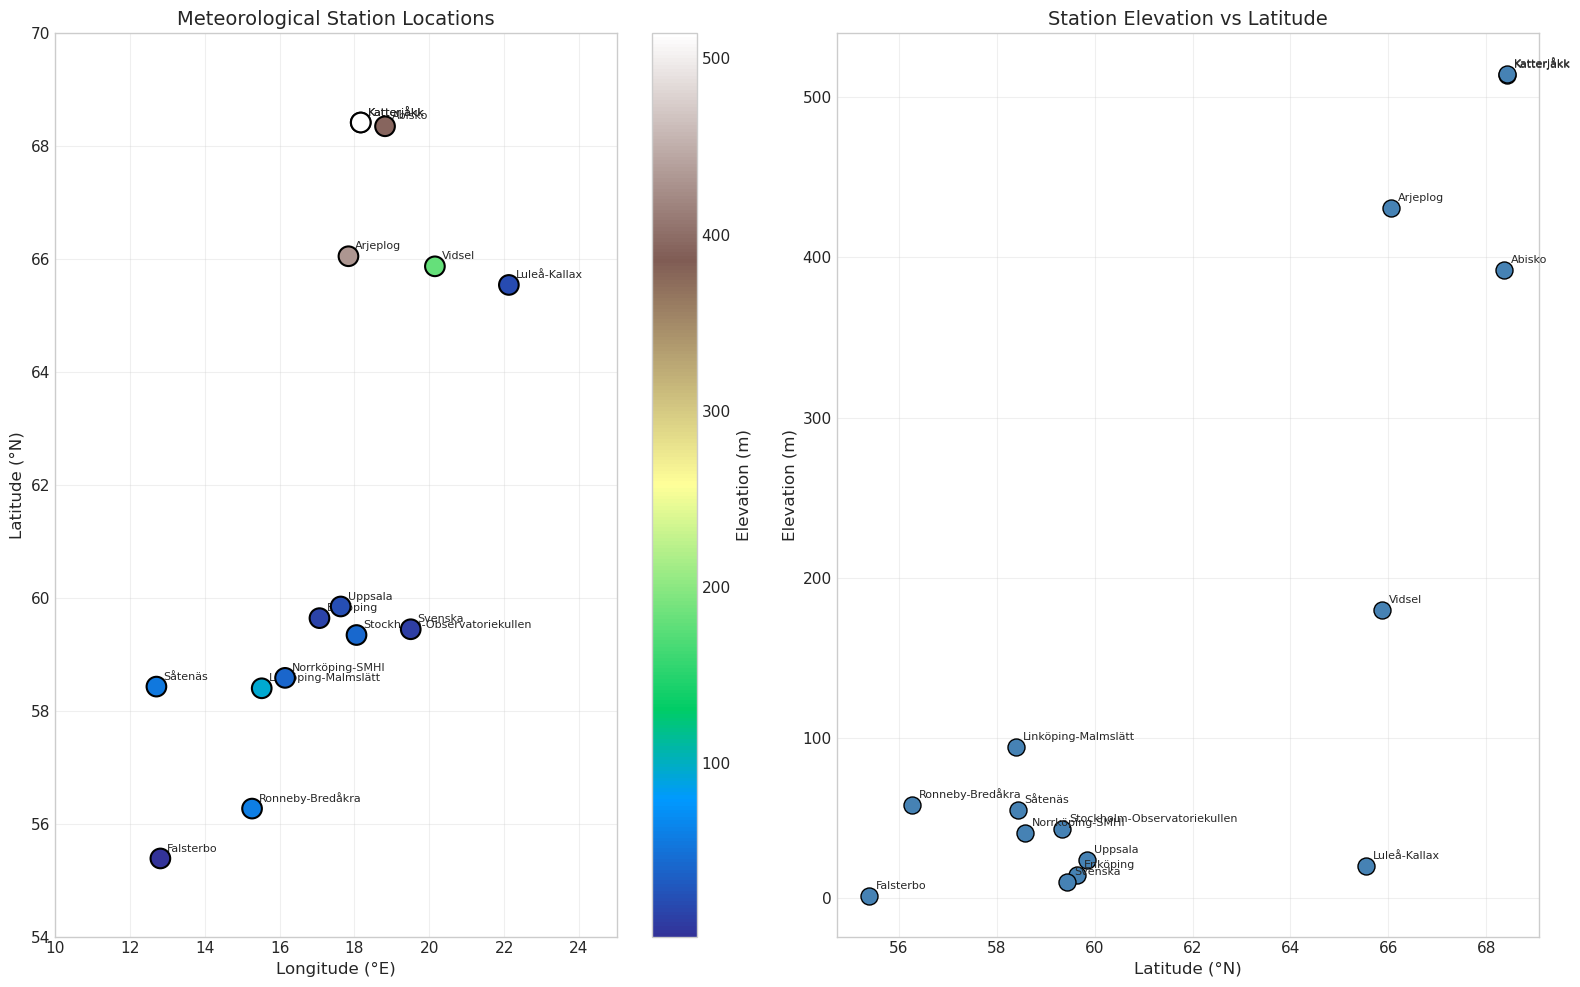


Geographic Coverage:
  Latitude:  55.38°N to 68.42°N (span: 13.04°)
  Longitude: 12.71°E to 22.12°E (span: 9.41°)
  Elevation: 2m to 514m


In [6]:
# Station locations map
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Map view
ax = axes[0]
scatter = ax.scatter(stations['Lon'], stations['Lat'], 
                     c=stations['Elev'], cmap='terrain', 
                     s=200, edgecolors='black', linewidth=1.5, zorder=5)

# Add station labels
for _, row in stations.iterrows():
    ax.annotate(row['Name'].split()[0], (row['Lon'], row['Lat']), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.colorbar(scatter, ax=ax, label='Elevation (m)')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title('Meteorological Station Locations')
ax.grid(True, alpha=0.3)
ax.set_xlim(10, 25)
ax.set_ylim(54, 70)

# Elevation vs Latitude plot
ax = axes[1]
ax.scatter(stations['Lat'], stations['Elev'], s=150, c='steelblue', edgecolors='black')
for _, row in stations.iterrows():
    ax.annotate(row['Name'].split()[0], (row['Lat'], row['Elev']), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('Elevation (m)')
ax.set_title('Station Elevation vs Latitude')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Geographic summary
print(f"\nGeographic Coverage:")
print(f"  Latitude:  {stations['Lat'].min():.2f}°N to {stations['Lat'].max():.2f}°N (span: {stations['Lat'].max()-stations['Lat'].min():.2f}°)")
print(f"  Longitude: {stations['Lon'].min():.2f}°E to {stations['Lon'].max():.2f}°E (span: {stations['Lon'].max()-stations['Lon'].min():.2f}°)")
print(f"  Elevation: {stations['Elev'].min():.0f}m to {stations['Elev'].max():.0f}m")

---
## 3. Data Coverage Analysis

In [7]:
# Define parameter columns
metadata_cols = ['date', 'station_id', 'station_name', 'latitude', 'longitude', 'elevation']
param_cols = [col for col in df.columns if col not in metadata_cols]

print(f"Parameter columns ({len(param_cols)}): {param_cols}")

Parameter columns (11): ['snow', 'temp', 'temp_min', 'temp_max', 'precip', 'wind', 'humidity', 'pressure', 'dew_point', 'cloud_cover', 'ground_state']


In [8]:
# Overall coverage statistics
coverage_stats = pd.DataFrame({
    'Total': len(df),
    'Non-Null': df[param_cols].notna().sum(),
    'Null': df[param_cols].isna().sum(),
    'Coverage %': (df[param_cols].notna().sum() / len(df) * 100).round(1),
    'Zero Count': (df[param_cols] == 0).sum(),
    'Non-Zero': ((df[param_cols] != 0) & df[param_cols].notna()).sum(),
})
coverage_stats = coverage_stats.sort_values('Coverage %', ascending=False)

print("=" * 80)
print("PARAMETER COVERAGE SUMMARY")
print("=" * 80)
display(coverage_stats)

PARAMETER COVERAGE SUMMARY


,Total,Non-Null,Null,Coverage %,Zero Count,Non-Zero
wind,44981,37032,7949,82.300,84,36948
pressure,44981,33125,11856,73.600,0,33125
dew_point,44981,33070,11911,73.500,11,33059
cloud_cover,44981,28397,16584,63.100,907,27490
snow,44981,26416,18565,58.700,19243,7173
ground_state,44981,25006,19975,55.600,9608,15398
humidity,44981,13518,31463,30.100,71,13447
precip,44981,11480,33501,25.500,5848,5632
temp,44981,0,44981,0.000,0,0
temp_min,44981,0,44981,0.000,0,0


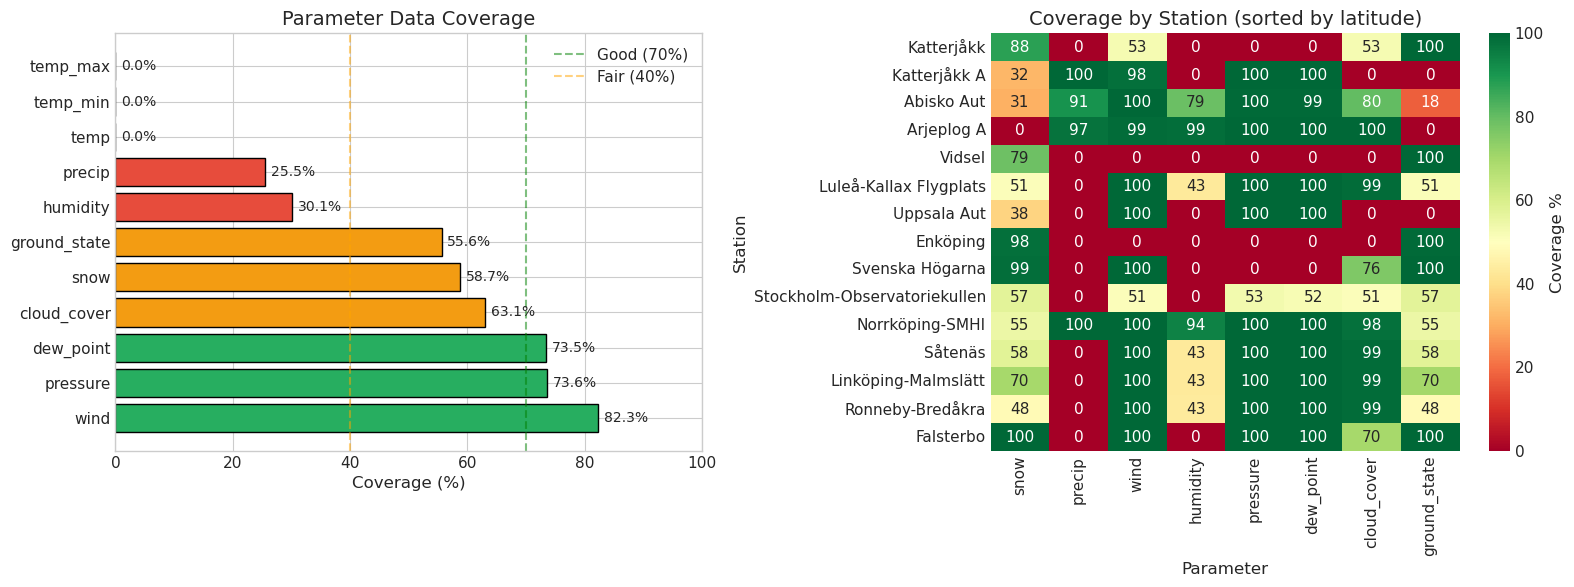

In [9]:
# Visualize coverage
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = ['#27ae60' if x >= 70 else '#f39c12' if x >= 40 else '#e74c3c' for x in coverage_stats['Coverage %']]
ax = axes[0]
bars = ax.barh(coverage_stats.index, coverage_stats['Coverage %'], color=colors, edgecolor='black')
ax.set_xlabel('Coverage (%)')
ax.set_title('Parameter Data Coverage')
ax.axvline(x=70, color='green', linestyle='--', alpha=0.5, label='Good (70%)')
ax.axvline(x=40, color='orange', linestyle='--', alpha=0.5, label='Fair (40%)')
ax.legend()
for i, (idx, row) in enumerate(coverage_stats.iterrows()):
    ax.text(row['Coverage %'] + 1, i, f"{row['Coverage %']:.1f}%", va='center', fontsize=10)
ax.set_xlim(0, 100)

# Coverage by station heatmap
ax = axes[1]
station_coverage = df.groupby('station_name')[param_cols].apply(lambda x: x.notna().mean() * 100)
station_coverage = station_coverage.reindex(stations.sort_values('Lat', ascending=False)['Name'])

# Only show columns with some data
cols_with_data = [c for c in param_cols if station_coverage[c].sum() > 0]
sns.heatmap(station_coverage[cols_with_data], annot=True, fmt='.0f', cmap='RdYlGn', 
            vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'Coverage %'})
ax.set_title('Coverage by Station (sorted by latitude)')
ax.set_xlabel('Parameter')
ax.set_ylabel('Station')

plt.tight_layout()
plt.show()

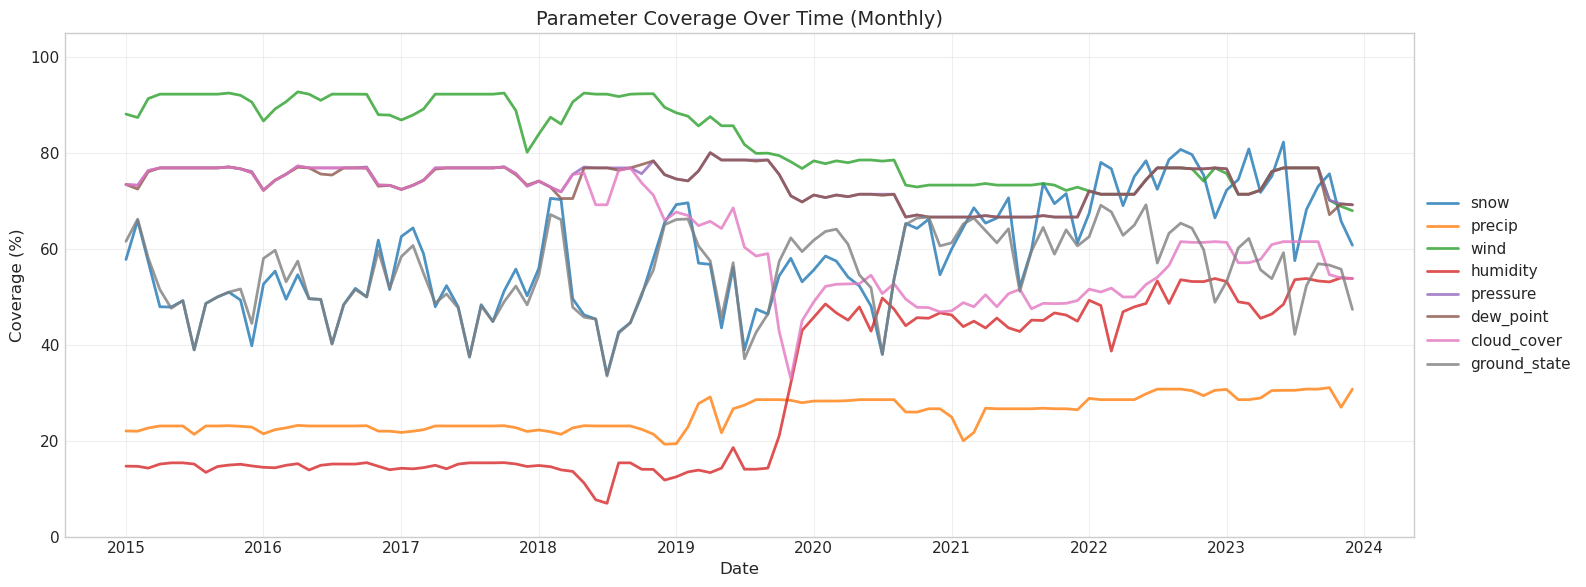

In [10]:
# Coverage over time
fig, ax = plt.subplots(figsize=(16, 6))

# Monthly coverage
cols_to_plot = [c for c in param_cols if df[c].notna().sum() > 0]
for col in cols_to_plot:
    monthly = df.groupby(df['date'].dt.to_period('M'))[col].apply(lambda x: x.notna().mean() * 100)
    monthly.index = monthly.index.to_timestamp()
    ax.plot(monthly.index, monthly.values, label=col, linewidth=2, alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('Coverage (%)')
ax.set_title('Parameter Coverage Over Time (Monthly)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Statistical Summary

In [11]:
# Detailed statistics for parameters with data
cols_with_data = [c for c in param_cols if df[c].notna().sum() > 0]

print("=" * 100)
print("DESCRIPTIVE STATISTICS")
print("=" * 100)
display(df[cols_with_data].describe().round(3))

DESCRIPTIVE STATISTICS


,snow,precip,wind,humidity,pressure,dew_point,cloud_cover,ground_state
count,26416.000,11480.000,37032.000,13518.000,33125.000,33070.000,28397.000,25006.000
mean,0.118,1.623,3.769,4.834,1011.700,2.299,60.511,5.216
std,0.321,3.747,2.485,1.718,11.740,8.185,31.977,7.008
min,-0.020,-0.200,0.000,-1.000,947.975,-37.750,0.000,0.000
25%,0.000,0.000,2.042,3.800,1004.596,-2.707,34.583,0.000
50%,0.000,0.000,3.083,4.931,1012.462,2.646,64.750,1.000
75%,0.010,1.400,4.800,6.042,1019.417,8.592,90.400,12.000
max,2.290,76.300,20.600,9.000,1053.900,21.346,113.000,19.000


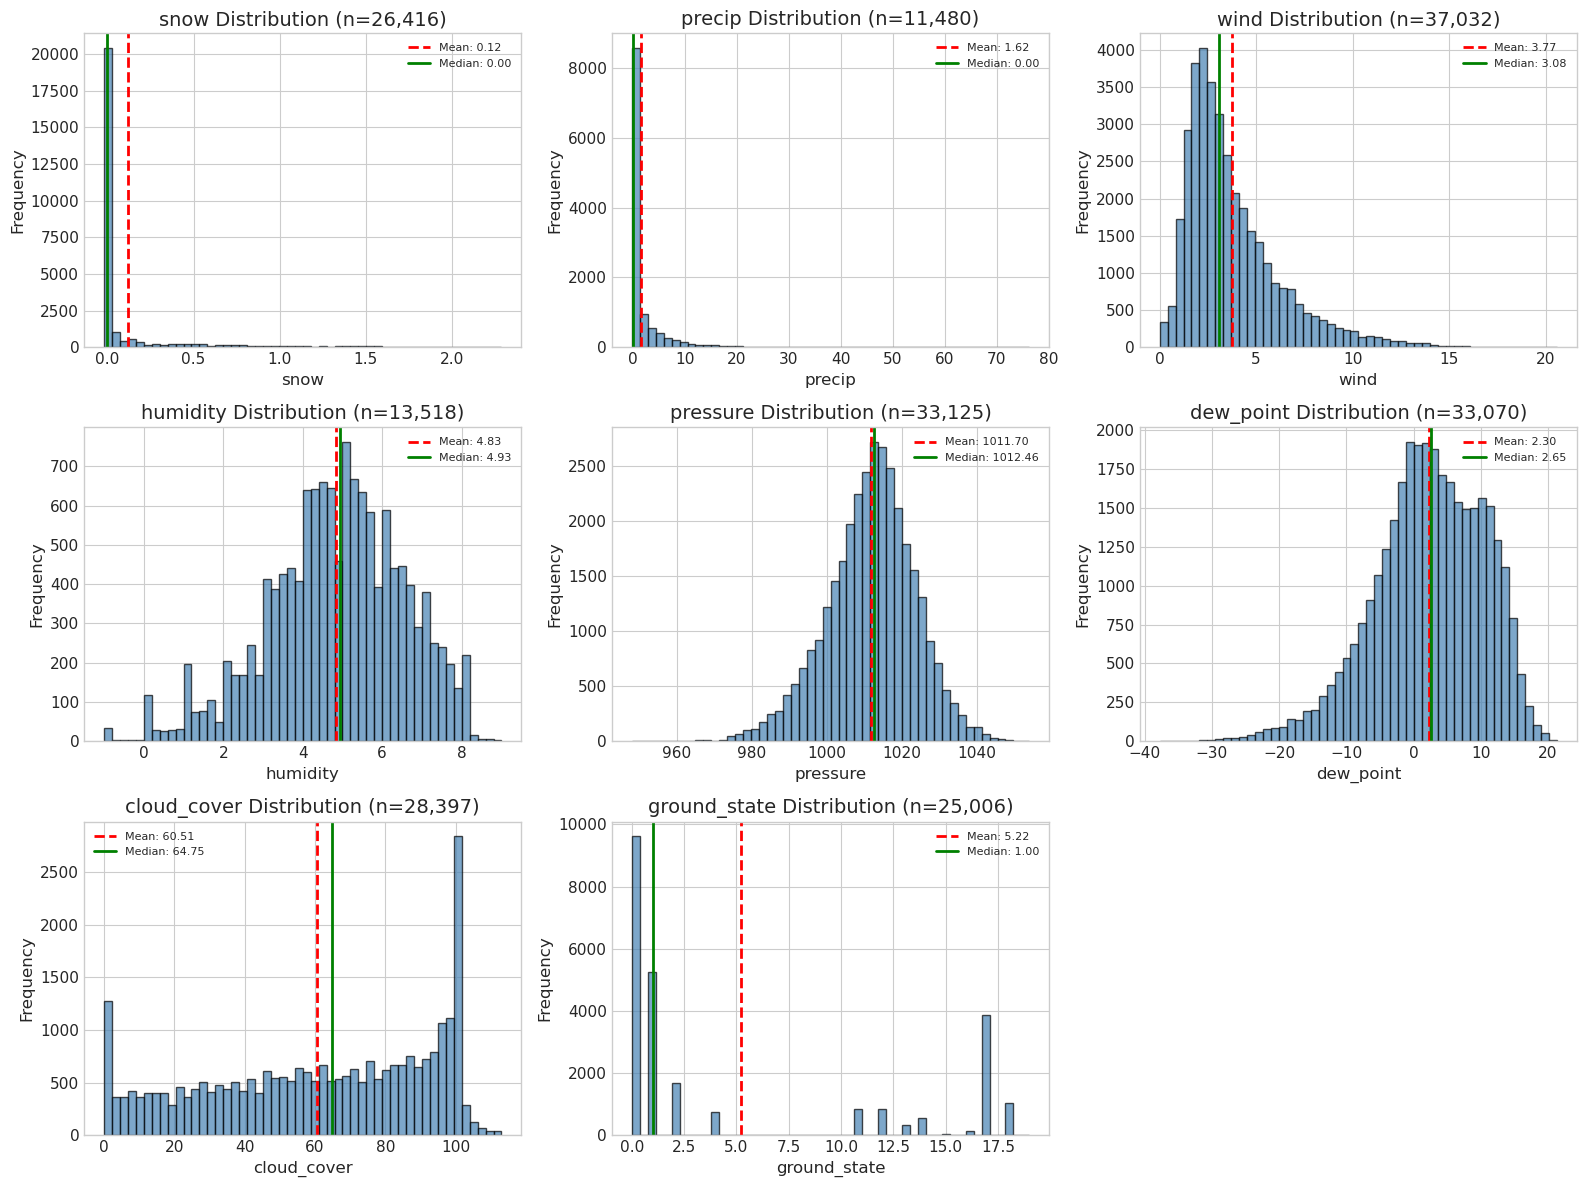

In [12]:
# Distribution plots
n_params = len(cols_with_data)
n_cols = 3
n_rows = (n_params + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_with_data):
    ax = axes[i]
    data = df[col].dropna()
    
    # Histogram
    ax.hist(data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    
    # Add statistics
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
    
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{col} Distribution (n={len(data):,})')
    ax.legend(fontsize=8)

# Hide empty subplots
for i in range(len(cols_with_data), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

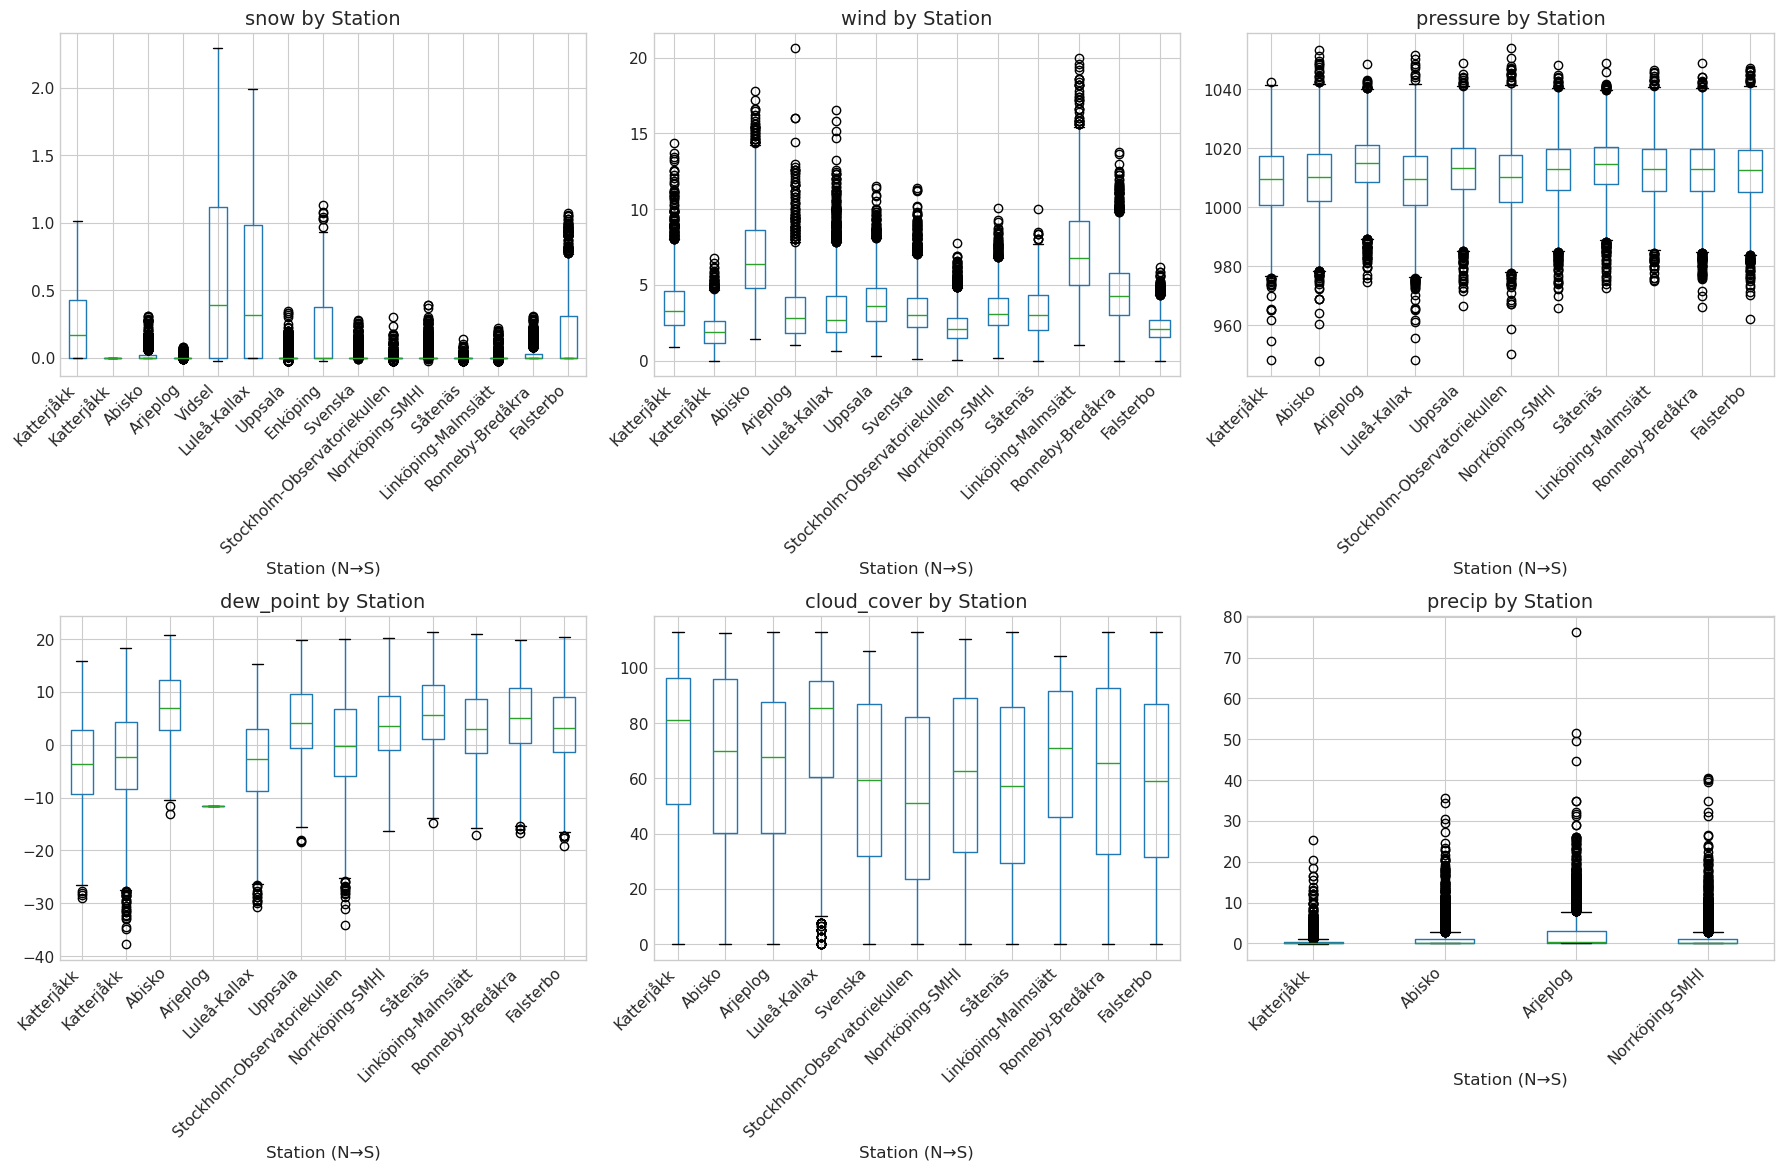

In [13]:
# Box plots by station
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

plot_params = ['snow', 'wind', 'pressure', 'dew_point', 'cloud_cover', 'precip']
plot_params = [p for p in plot_params if p in cols_with_data]

for i, col in enumerate(plot_params[:6]):
    ax = axes[i]
    # Order stations by latitude
    station_order = stations.sort_values('Lat', ascending=False)['Name'].tolist()
    valid_stations = [s for s in station_order if s in df[df[col].notna()]['station_name'].unique()]
    
    df_plot = df[df['station_name'].isin(valid_stations)]
    df_plot.boxplot(column=col, by='station_name', ax=ax, 
                    positions=range(len(valid_stations)),
                    vert=True)
    ax.set_xticklabels([s.split()[0] for s in valid_stations], rotation=45, ha='right')
    ax.set_xlabel('Station (N→S)')
    ax.set_title(f'{col} by Station')
    plt.suptitle('')

for i in range(len(plot_params), 6):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

---
## 5. Snow Depth Analysis (Primary Target)

In [14]:
# Convert snow to cm
df['snow_cm'] = df['snow'] * 100

# Snow data subset
snow_df = df[df['snow'].notna()].copy()
print(f"Records with snow data: {len(snow_df):,} ({len(snow_df)/len(df)*100:.1f}% of total)")
print(f"Stations with snow data: {snow_df['station_name'].nunique()}")

print("\nSnow Depth Statistics (cm):")
print(snow_df['snow_cm'].describe())

Records with snow data: 26,416 (58.7% of total)
Stations with snow data: 15

Snow Depth Statistics (cm):
count   26416.000
mean       11.812
std        32.117
min        -2.000
25%         0.000
50%         0.000
75%         1.000
max       229.000
Name: snow_cm, dtype: float64


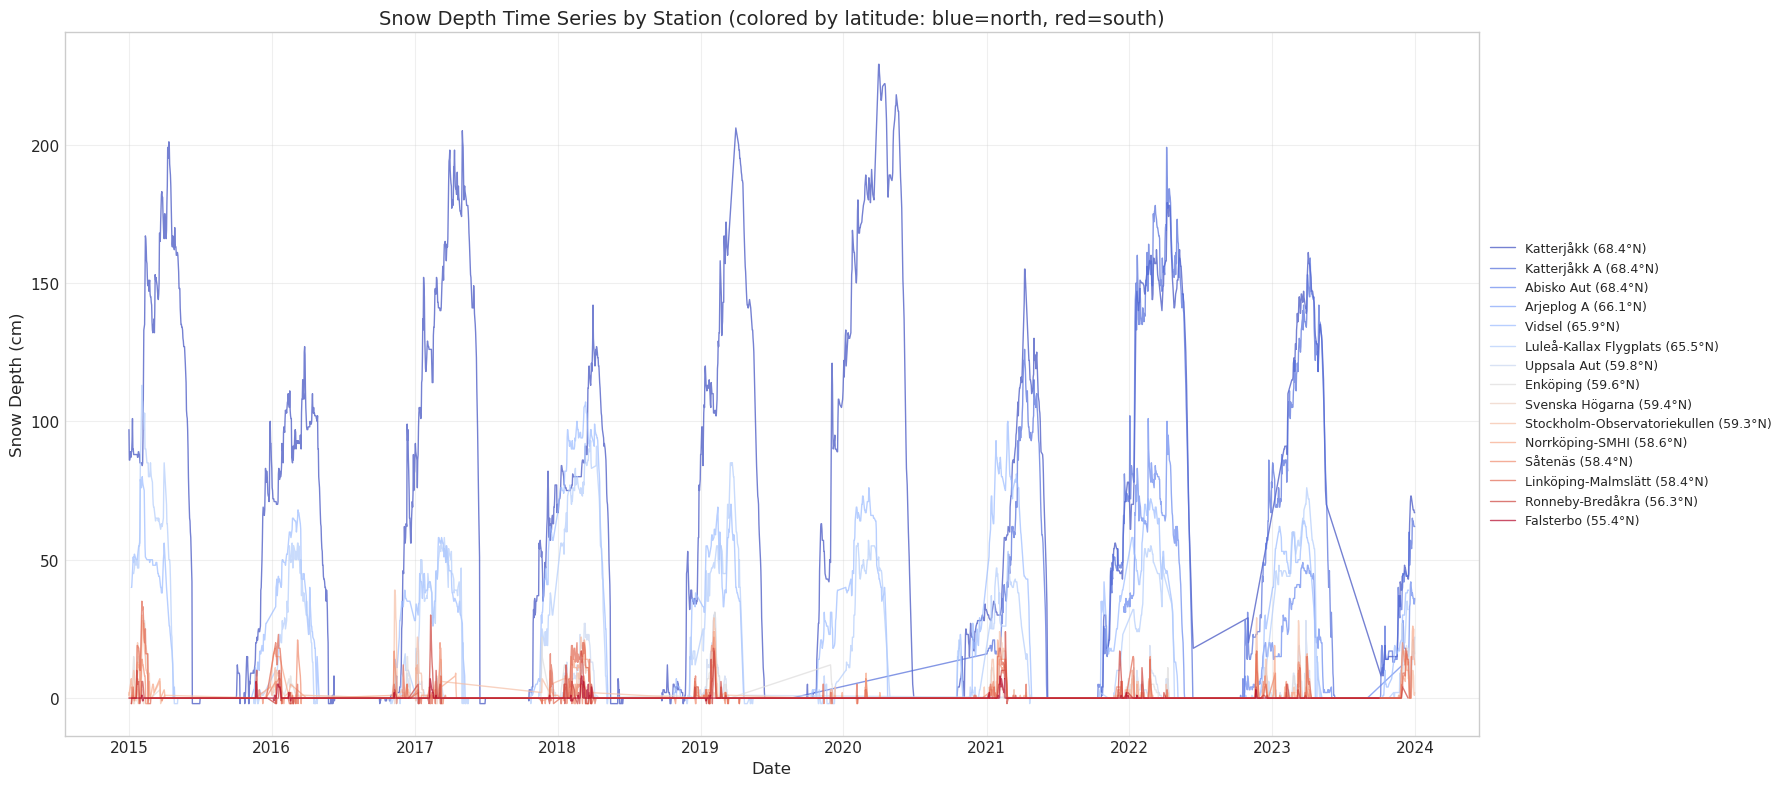

In [15]:
# Snow depth time series by station
fig, ax = plt.subplots(figsize=(18, 8))

# Sort stations by latitude (north first)
station_order = stations.sort_values('Lat', ascending=False)['Name'].tolist()
colors = plt.cm.coolwarm(np.linspace(0, 1, len(station_order)))

for i, station in enumerate(station_order):
    station_data = snow_df[snow_df['station_name'] == station]
    if len(station_data) > 0:
        ax.plot(station_data['date'], station_data['snow_cm'], 
                label=f"{station} ({stations[stations['Name']==station]['Lat'].values[0]:.1f}°N)",
                alpha=0.7, linewidth=1, color=colors[i])

ax.set_xlabel('Date')
ax.set_ylabel('Snow Depth (cm)')
ax.set_title('Snow Depth Time Series by Station (colored by latitude: blue=north, red=south)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

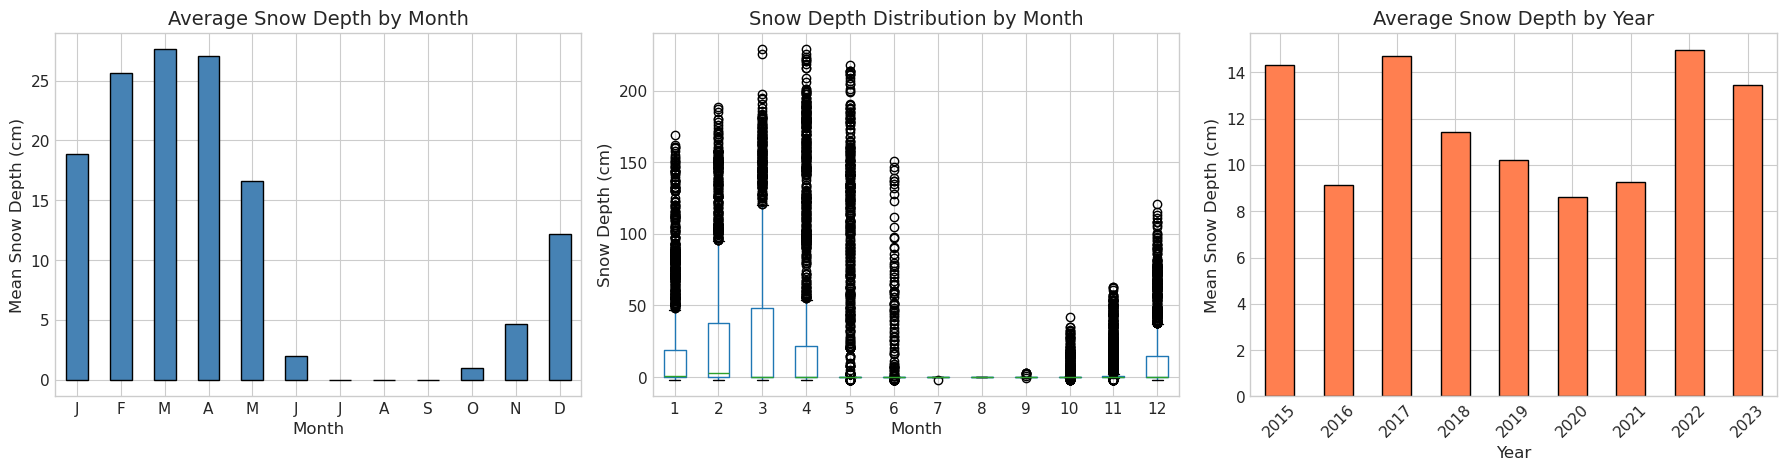

In [16]:
# Seasonal snow patterns
snow_df['month'] = snow_df['date'].dt.month
snow_df['year'] = snow_df['date'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Monthly average
ax = axes[0]
monthly_avg = snow_df.groupby('month')['snow_cm'].mean()
monthly_avg.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Month')
ax.set_ylabel('Mean Snow Depth (cm)')
ax.set_title('Average Snow Depth by Month')
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], rotation=0)

# Monthly box plot
ax = axes[1]
snow_df.boxplot(column='snow_cm', by='month', ax=ax)
ax.set_xlabel('Month')
ax.set_ylabel('Snow Depth (cm)')
ax.set_title('Snow Depth Distribution by Month')
plt.suptitle('')

# Year-over-year
ax = axes[2]
yearly_avg = snow_df.groupby('year')['snow_cm'].mean()
yearly_avg.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Snow Depth (cm)')
ax.set_title('Average Snow Depth by Year')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

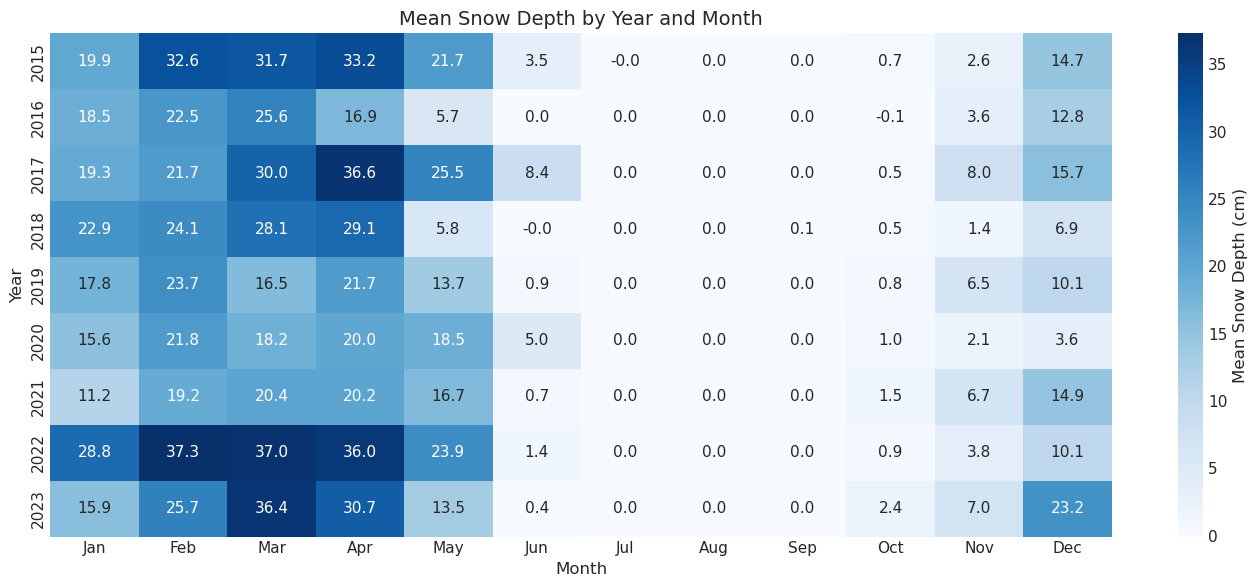

In [17]:
# Monthly heatmap by year
fig, ax = plt.subplots(figsize=(14, 6))

monthly_pivot = snow_df.pivot_table(values='snow_cm', index='year', columns='month', aggfunc='mean')
sns.heatmap(monthly_pivot, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            cbar_kws={'label': 'Mean Snow Depth (cm)'})
ax.set_xlabel('Month')
ax.set_ylabel('Year')
ax.set_title('Mean Snow Depth by Year and Month')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.show()

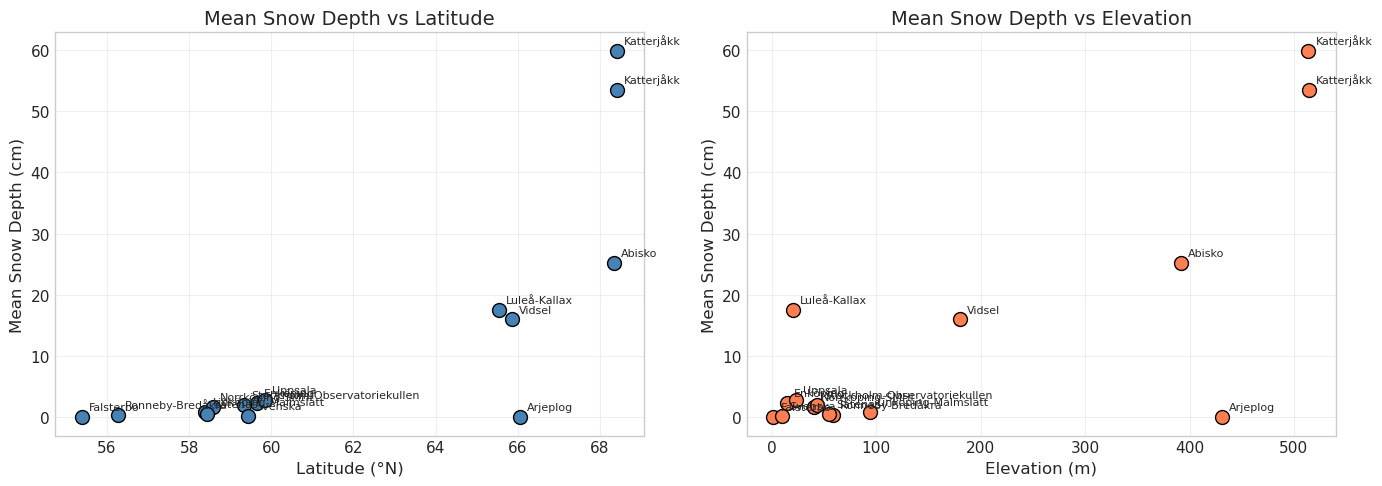

In [18]:
# Snow by latitude
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average snow by station latitude
ax = axes[0]
station_snow = snow_df.groupby(['station_name', 'latitude'])['snow_cm'].mean().reset_index()
ax.scatter(station_snow['latitude'], station_snow['snow_cm'], s=100, c='steelblue', edgecolors='black')
for _, row in station_snow.iterrows():
    ax.annotate(row['station_name'].split()[0], (row['latitude'], row['snow_cm']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('Mean Snow Depth (cm)')
ax.set_title('Mean Snow Depth vs Latitude')
ax.grid(True, alpha=0.3)

# Snow by elevation
ax = axes[1]
station_snow = snow_df.groupby(['station_name', 'elevation'])['snow_cm'].mean().reset_index()
ax.scatter(station_snow['elevation'], station_snow['snow_cm'], s=100, c='coral', edgecolors='black')
for _, row in station_snow.iterrows():
    ax.annotate(row['station_name'].split()[0], (row['elevation'], row['snow_cm']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Mean Snow Depth (cm)')
ax.set_title('Mean Snow Depth vs Elevation')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Meteorological Parameters Analysis

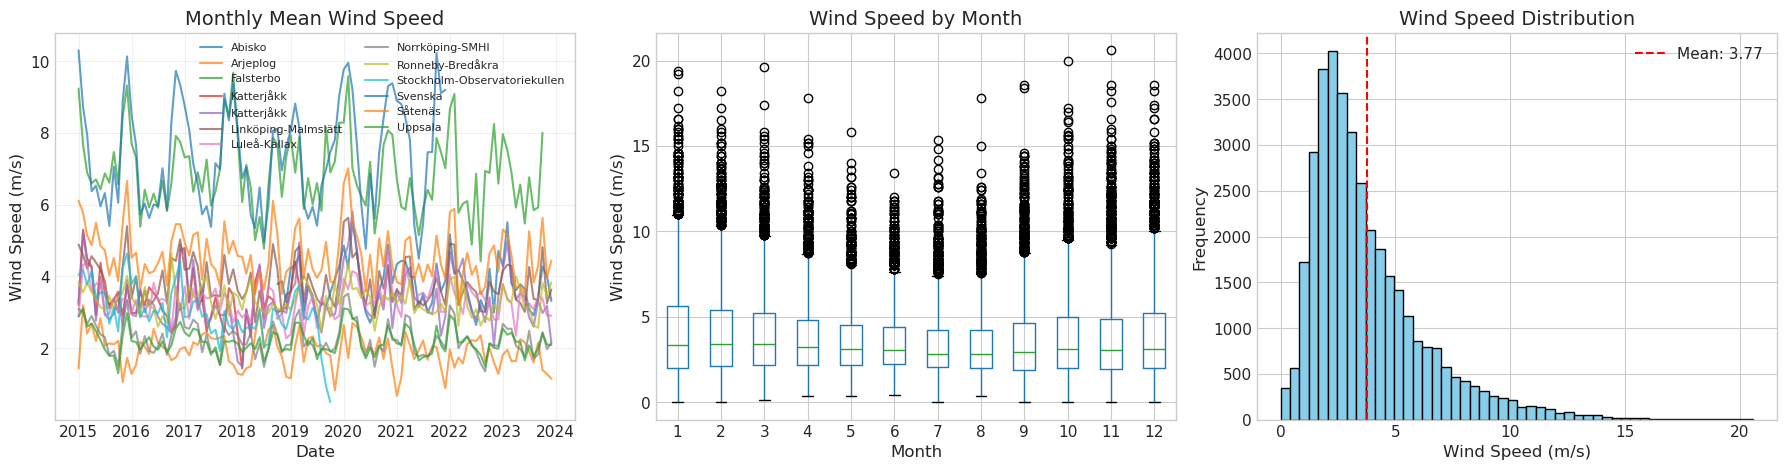

In [19]:
# Wind speed analysis
if 'wind' in cols_with_data:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Time series
    ax = axes[0]
    for station in df['station_name'].unique():
        data = df[(df['station_name'] == station) & df['wind'].notna()]
        if len(data) > 100:
            monthly = data.groupby(data['date'].dt.to_period('M'))['wind'].mean()
            monthly.index = monthly.index.to_timestamp()
            ax.plot(monthly.index, monthly.values, alpha=0.7, label=station.split()[0])
    ax.set_xlabel('Date')
    ax.set_ylabel('Wind Speed (m/s)')
    ax.set_title('Monthly Mean Wind Speed')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    
    # Monthly pattern
    ax = axes[1]
    wind_df = df[df['wind'].notna()].copy()
    wind_df['month'] = wind_df['date'].dt.month
    wind_df.boxplot(column='wind', by='month', ax=ax)
    ax.set_xlabel('Month')
    ax.set_ylabel('Wind Speed (m/s)')
    ax.set_title('Wind Speed by Month')
    plt.suptitle('')
    
    # Distribution
    ax = axes[2]
    df['wind'].hist(bins=50, ax=ax, color='skyblue', edgecolor='black')
    ax.set_xlabel('Wind Speed (m/s)')
    ax.set_ylabel('Frequency')
    ax.set_title('Wind Speed Distribution')
    ax.axvline(df['wind'].mean(), color='red', linestyle='--', label=f"Mean: {df['wind'].mean():.2f}")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

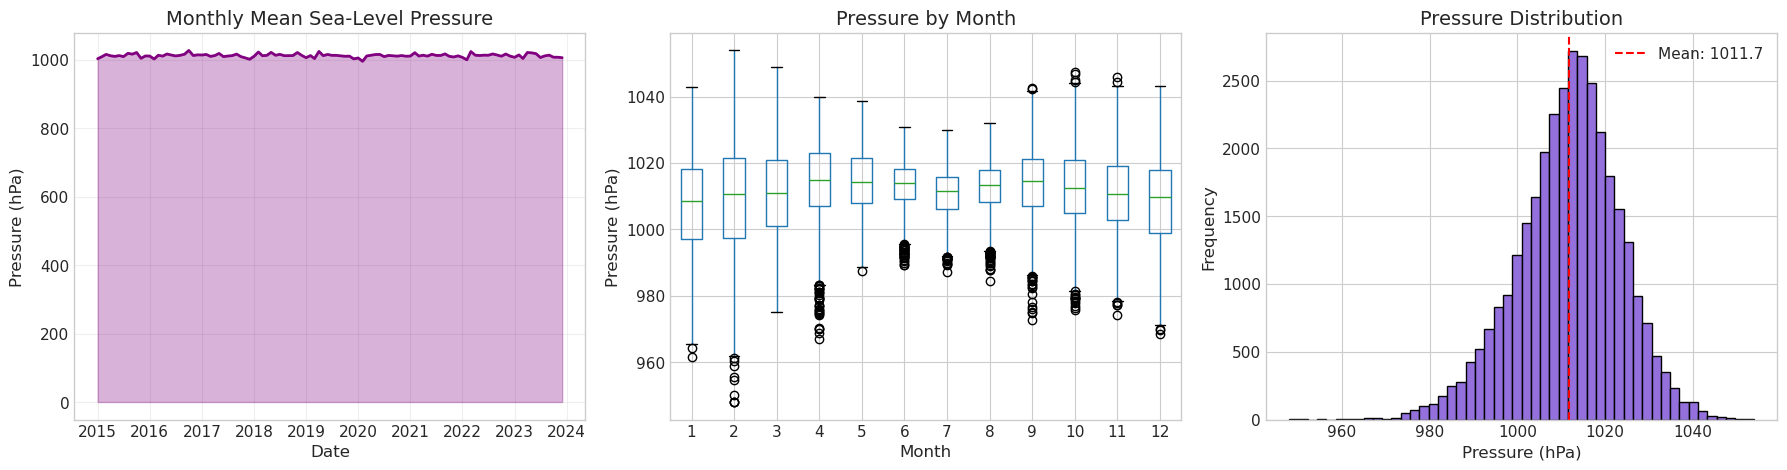

In [20]:
# Pressure analysis
if 'pressure' in cols_with_data:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Time series
    ax = axes[0]
    pressure_df = df[df['pressure'].notna()].copy()
    monthly = pressure_df.groupby(pressure_df['date'].dt.to_period('M'))['pressure'].mean()
    monthly.index = monthly.index.to_timestamp()
    ax.plot(monthly.index, monthly.values, color='purple', linewidth=2)
    ax.fill_between(monthly.index, monthly.values, alpha=0.3, color='purple')
    ax.set_xlabel('Date')
    ax.set_ylabel('Pressure (hPa)')
    ax.set_title('Monthly Mean Sea-Level Pressure')
    ax.grid(True, alpha=0.3)
    
    # Monthly pattern
    ax = axes[1]
    pressure_df['month'] = pressure_df['date'].dt.month
    pressure_df.boxplot(column='pressure', by='month', ax=ax)
    ax.set_xlabel('Month')
    ax.set_ylabel('Pressure (hPa)')
    ax.set_title('Pressure by Month')
    plt.suptitle('')
    
    # Distribution
    ax = axes[2]
    df['pressure'].hist(bins=50, ax=ax, color='mediumpurple', edgecolor='black')
    ax.set_xlabel('Pressure (hPa)')
    ax.set_ylabel('Frequency')
    ax.set_title('Pressure Distribution')
    ax.axvline(df['pressure'].mean(), color='red', linestyle='--', label=f"Mean: {df['pressure'].mean():.1f}")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

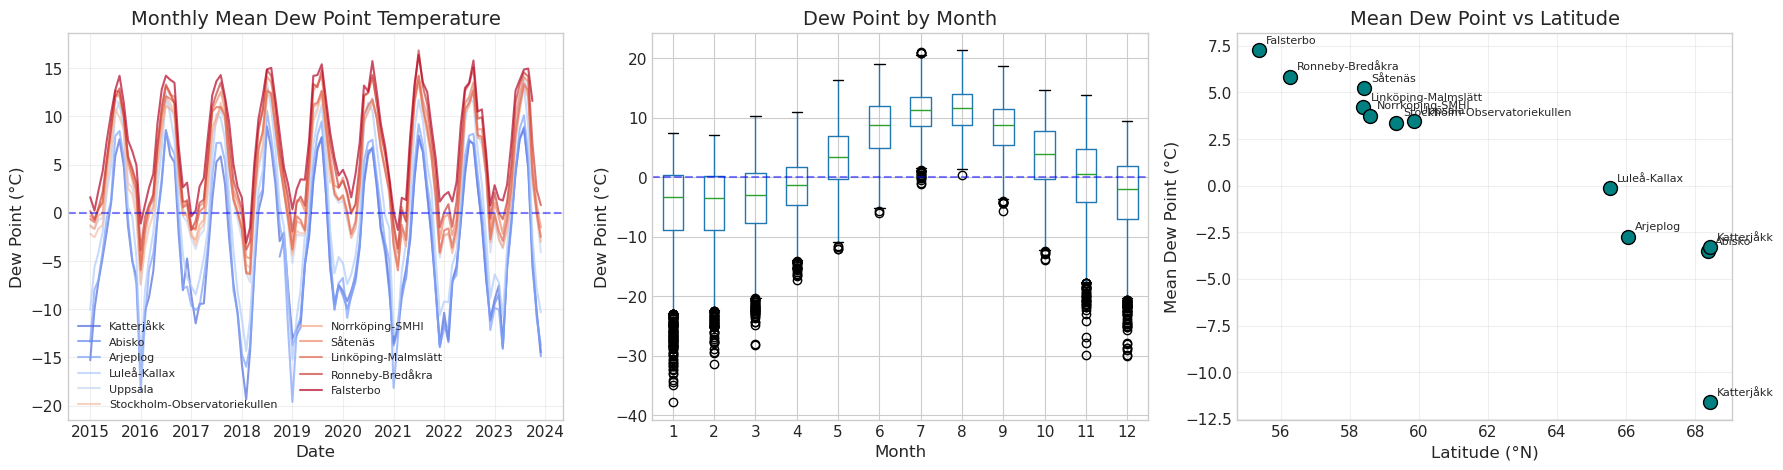

In [21]:
# Dew point analysis (proxy for temperature since temp is missing)
if 'dew_point' in cols_with_data:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Time series by station
    ax = axes[0]
    station_order = stations.sort_values('Lat', ascending=False)['Name'].tolist()
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(station_order)))
    
    for i, station in enumerate(station_order):
        data = df[(df['station_name'] == station) & df['dew_point'].notna()]
        if len(data) > 100:
            monthly = data.groupby(data['date'].dt.to_period('M'))['dew_point'].mean()
            monthly.index = monthly.index.to_timestamp()
            ax.plot(monthly.index, monthly.values, alpha=0.7, color=colors[i], label=station.split()[0])
    ax.set_xlabel('Date')
    ax.set_ylabel('Dew Point (°C)')
    ax.set_title('Monthly Mean Dew Point Temperature')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='blue', linestyle='--', alpha=0.5)
    
    # Monthly pattern
    ax = axes[1]
    dew_df = df[df['dew_point'].notna()].copy()
    dew_df['month'] = dew_df['date'].dt.month
    dew_df.boxplot(column='dew_point', by='month', ax=ax)
    ax.set_xlabel('Month')
    ax.set_ylabel('Dew Point (°C)')
    ax.set_title('Dew Point by Month')
    ax.axhline(0, color='blue', linestyle='--', alpha=0.5)
    plt.suptitle('')
    
    # By latitude
    ax = axes[2]
    station_dew = dew_df.groupby(['station_name', 'latitude'])['dew_point'].mean().reset_index()
    ax.scatter(station_dew['latitude'], station_dew['dew_point'], s=100, c='teal', edgecolors='black')
    for _, row in station_dew.iterrows():
        ax.annotate(row['station_name'].split()[0], (row['latitude'], row['dew_point']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax.set_xlabel('Latitude (°N)')
    ax.set_ylabel('Mean Dew Point (°C)')
    ax.set_title('Mean Dew Point vs Latitude')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

---
## 7. Correlation Analysis

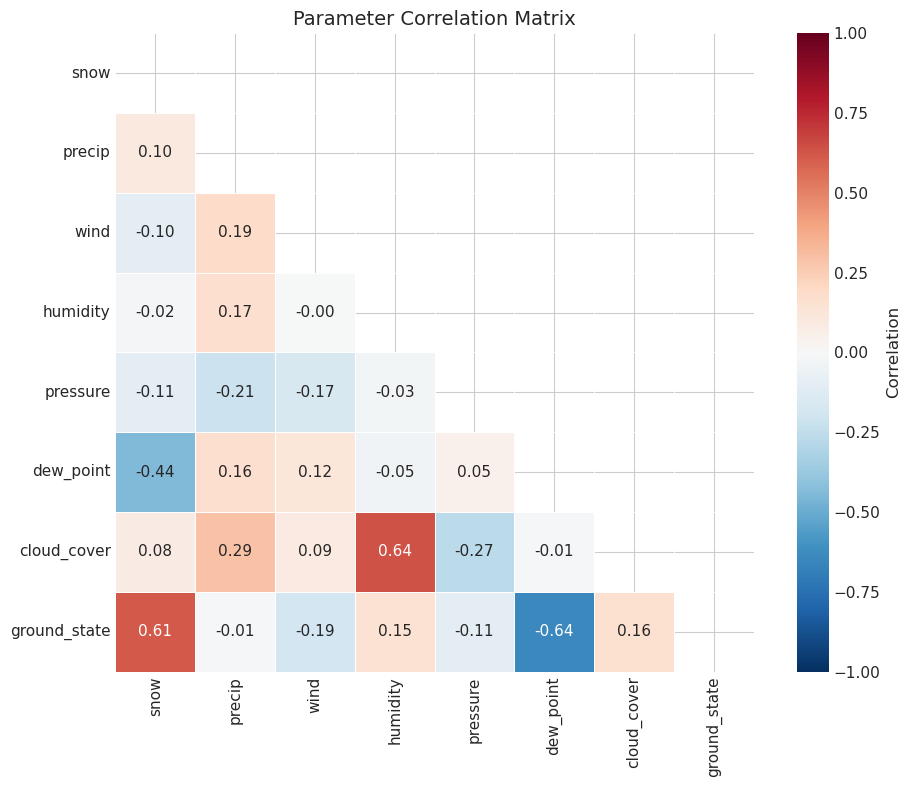


Notable Correlations with Snow:
  ground_state: 0.609 (positive)
  dew_point: -0.439 (negative)
  pressure: -0.106 (negative)
  wind: -0.102 (negative)
  precip: 0.100 (positive)


In [22]:
# Correlation matrix
corr_cols = [c for c in cols_with_data if df[c].notna().sum() > 1000]

if len(corr_cols) > 1:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    corr_matrix = df[corr_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax, square=True,
                linewidths=0.5, cbar_kws={'label': 'Correlation'})
    ax.set_title('Parameter Correlation Matrix')
    
    plt.tight_layout()
    plt.show()
    
    # Print notable correlations
    print("\nNotable Correlations with Snow:")
    if 'snow' in corr_cols:
        snow_corr = corr_matrix['snow'].drop('snow').sort_values(key=abs, ascending=False)
        for param, corr in snow_corr.items():
            if abs(corr) > 0.1:
                direction = "positive" if corr > 0 else "negative"
                print(f"  {param}: {corr:.3f} ({direction})")

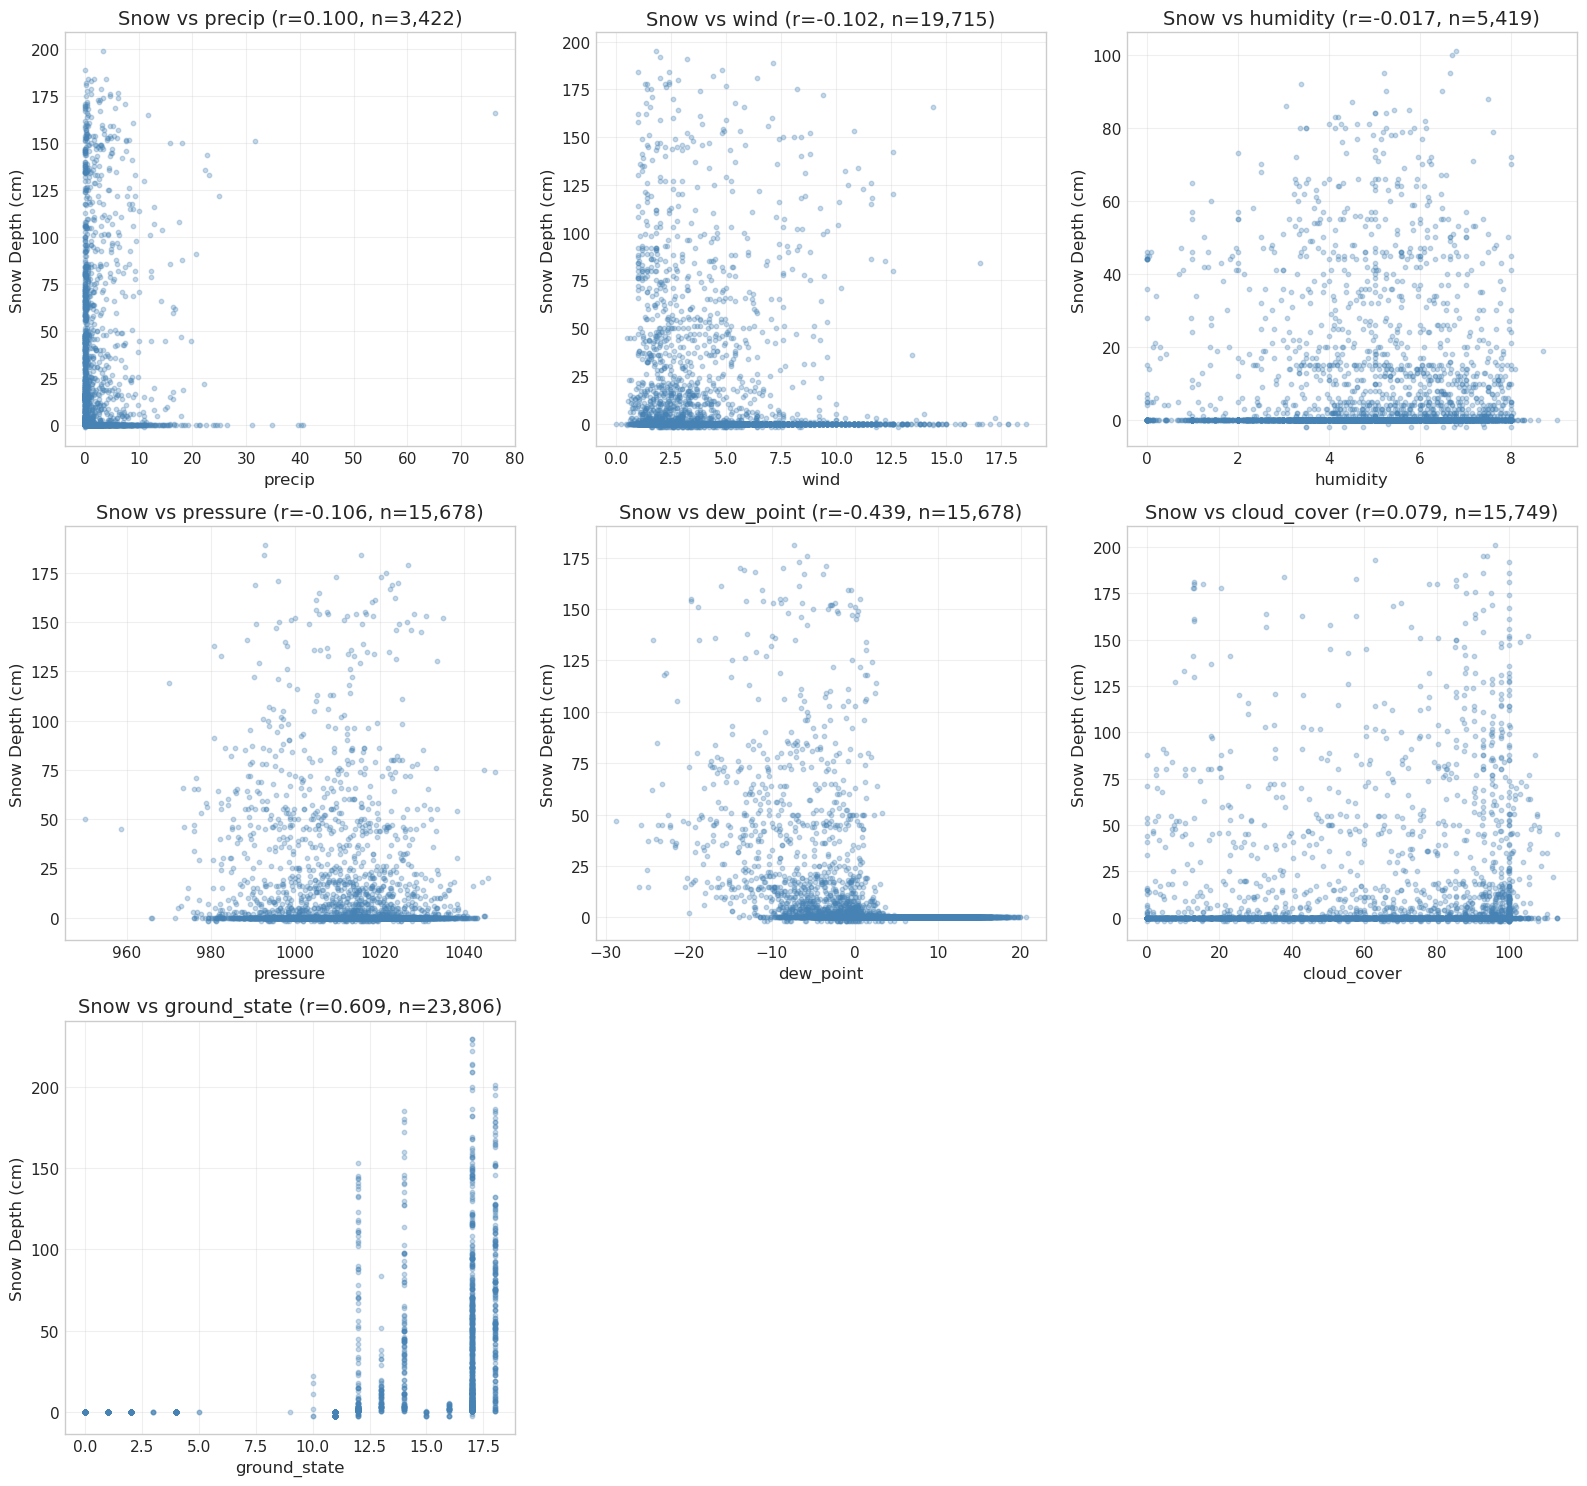

In [23]:
# Scatter plots: Snow vs other parameters
if 'snow' in df.columns and df['snow'].notna().sum() > 0:
    other_params = [c for c in corr_cols if c != 'snow' and c != 'snow_cm']
    
    n_params = len(other_params)
    n_cols = 3
    n_rows = (n_params + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
    axes = axes.flatten()
    
    for i, param in enumerate(other_params):
        ax = axes[i]
        
        # Get data where both are not null
        mask = df['snow'].notna() & df[param].notna()
        if mask.sum() > 100:
            # Sample for performance
            sample_idx = np.random.choice(np.where(mask)[0], min(5000, mask.sum()), replace=False)
            ax.scatter(df.loc[sample_idx, param], df.loc[sample_idx, 'snow_cm'], 
                      alpha=0.3, s=10, c='steelblue')
            
            # Add correlation
            corr = df.loc[mask, ['snow_cm', param]].corr().iloc[0, 1]
            ax.set_title(f'Snow vs {param} (r={corr:.3f}, n={mask.sum():,})')
        else:
            ax.text(0.5, 0.5, f'Insufficient\noverlapping data', ha='center', va='center',
                   transform=ax.transAxes, fontsize=12)
            ax.set_title(f'Snow vs {param}')
        
        ax.set_xlabel(param)
        ax.set_ylabel('Snow Depth (cm)')
        ax.grid(True, alpha=0.3)
    
    for i in range(len(other_params), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

---
## 8. Anomaly and Extreme Events Analysis

In [24]:
# Snow depth extremes
if df['snow'].notna().sum() > 0:
    print("=" * 70)
    print("SNOW DEPTH EXTREMES")
    print("=" * 70)
    
    p95 = df['snow_cm'].quantile(0.95)
    p99 = df['snow_cm'].quantile(0.99)
    
    print(f"\nPercentiles:")
    print(f"  95th: {p95:.1f} cm")
    print(f"  99th: {p99:.1f} cm")
    print(f"  Max:  {df['snow_cm'].max():.1f} cm")
    
    # Top 20 extreme events
    extreme = df.nlargest(20, 'snow_cm')[['date', 'station_name', 'latitude', 'elevation', 'snow_cm']]
    print(f"\nTop 20 Maximum Snow Depths:")
    display(extreme)

SNOW DEPTH EXTREMES

Percentiles:
  95th: 85.0 cm
  99th: 160.0 cm
  Max:  229.0 cm

Top 20 Maximum Snow Depths:


,date,station_name,latitude,elevation,snow_cm
11880,2020-03-31,Katterjåkk,68.421,513.910,229.000
11881,2020-04-01,Katterjåkk,68.421,513.910,229.000
11879,2020-03-30,Katterjåkk,68.421,513.910,226.000
11882,2020-04-02,Katterjåkk,68.421,513.910,226.000
11883,2020-04-03,Katterjåkk,68.421,513.910,224.000
11895,2020-04-15,Katterjåkk,68.421,513.910,222.000
11896,2020-04-16,Katterjåkk,68.421,513.910,222.000
11890,2020-04-10,Katterjåkk,68.421,513.910,221.000
11897,2020-04-17,Katterjåkk,68.421,513.910,221.000
11889,2020-04-09,Katterjåkk,68.421,513.910,219.000



Daily Snow Change Statistics (cm):
count   24219.000
mean       -0.003
std         2.228
min       -62.000
25%         0.000
50%         0.000
75%         0.000
max        70.000
Name: snow_change, dtype: float64


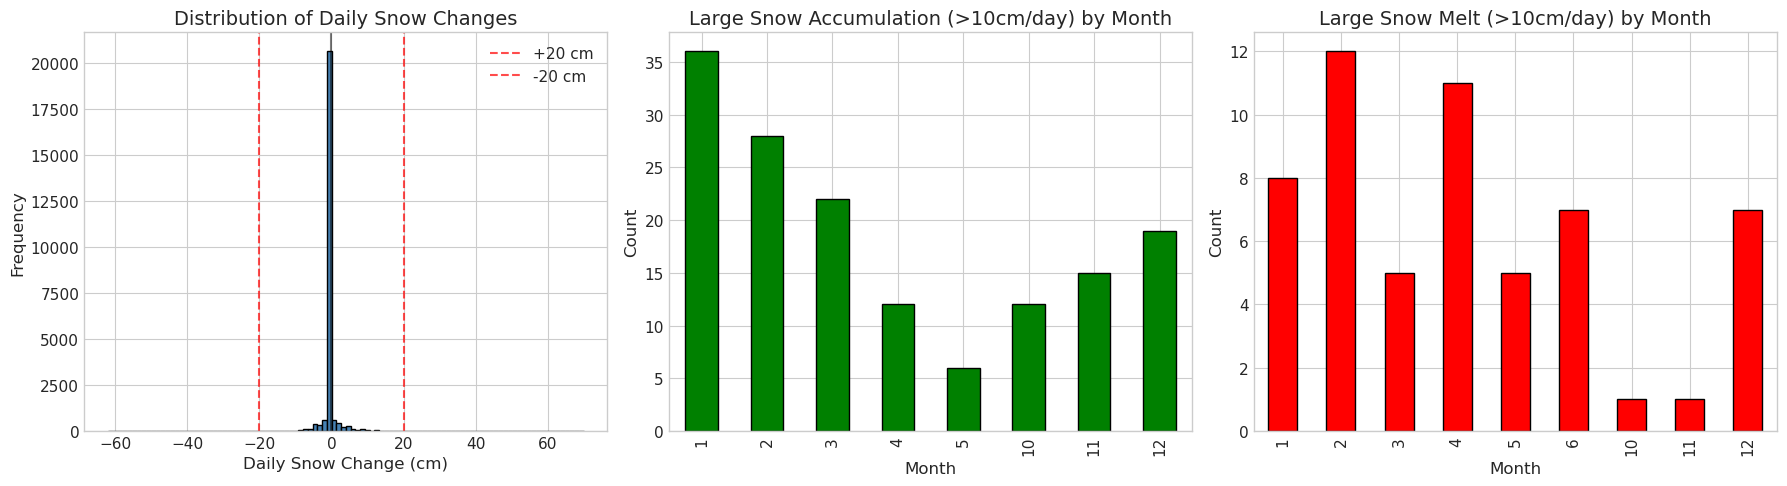


Extreme Snow Change Events:
  Large accumulations (>10 cm/day): 150
  Large melt events (>10 cm/day):   57


In [25]:
# Daily snow changes (for anomaly detection)
if df['snow'].notna().sum() > 0:
    df_sorted = df.sort_values(['station_name', 'date'])
    df_sorted['snow_change'] = df_sorted.groupby('station_name')['snow_cm'].diff()
    
    print("\nDaily Snow Change Statistics (cm):")
    print(df_sorted['snow_change'].describe())
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Distribution of changes
    ax = axes[0]
    df_sorted['snow_change'].hist(bins=100, ax=ax, color='steelblue', edgecolor='black')
    ax.set_xlabel('Daily Snow Change (cm)')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Daily Snow Changes')
    ax.axvline(0, color='black', linestyle='-', alpha=0.5)
    ax.axvline(20, color='red', linestyle='--', alpha=0.7, label='+20 cm')
    ax.axvline(-20, color='red', linestyle='--', alpha=0.7, label='-20 cm')
    ax.legend()
    
    # Large accumulation events
    ax = axes[1]
    large_acc = df_sorted[df_sorted['snow_change'] > 10].copy()
    if len(large_acc) > 0:
        large_acc['month'] = large_acc['date'].dt.month
        large_acc.groupby('month').size().plot(kind='bar', ax=ax, color='green', edgecolor='black')
        ax.set_xlabel('Month')
        ax.set_ylabel('Count')
        ax.set_title('Large Snow Accumulation (>10cm/day) by Month')
    
    # Large melt events
    ax = axes[2]
    large_melt = df_sorted[df_sorted['snow_change'] < -10].copy()
    if len(large_melt) > 0:
        large_melt['month'] = large_melt['date'].dt.month
        large_melt.groupby('month').size().plot(kind='bar', ax=ax, color='red', edgecolor='black')
        ax.set_xlabel('Month')
        ax.set_ylabel('Count')
        ax.set_title('Large Snow Melt (>10cm/day) by Month')
    
    plt.tight_layout()
    plt.show()
    
    # Extreme change events
    print(f"\nExtreme Snow Change Events:")
    print(f"  Large accumulations (>10 cm/day): {len(large_acc)}")
    print(f"  Large melt events (>10 cm/day):   {len(large_melt)}")

---
## 9. Data Quality Assessment

In [26]:
# Check for potential data quality issues
print("=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

# 1. Check for duplicate dates per station
duplicates = df.groupby(['station_name', 'date']).size()
dup_count = (duplicates > 1).sum()
print(f"\n1. Duplicate date entries per station: {dup_count}")

# 2. Check for outliers
print(f"\n2. Potential Outliers (beyond 3 std):")
for col in cols_with_data:
    data = df[col].dropna()
    if len(data) > 0:
        mean, std = data.mean(), data.std()
        outliers = ((data < mean - 3*std) | (data > mean + 3*std)).sum()
        if outliers > 0:
            print(f"   {col}: {outliers} values ({outliers/len(data)*100:.2f}%)")

# 3. Check for negative values where they shouldn't exist
print(f"\n3. Unexpected Negative Values:")
non_negative_cols = ['snow', 'wind', 'humidity', 'cloud_cover', 'precip']
for col in non_negative_cols:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            print(f"   {col}: {neg_count} negative values")

# 4. Date gaps
print(f"\n4. Date Coverage per Station:")
for station in df['station_name'].unique():
    station_df = df[df['station_name'] == station]
    date_range = (station_df['date'].max() - station_df['date'].min()).days + 1
    actual_days = len(station_df)
    coverage = actual_days / date_range * 100
    print(f"   {station[:20]:<20}: {actual_days:>4} days / {date_range:>4} possible ({coverage:>5.1f}%)")

DATA QUALITY ASSESSMENT

1. Duplicate date entries per station: 0

2. Potential Outliers (beyond 3 std):
   snow: 883 values (3.34%)
   precip: 277 values (2.41%)
   wind: 621 values (1.68%)
   humidity: 41 values (0.30%)
   pressure: 151 values (0.46%)
   dew_point: 212 values (0.64%)

3. Unexpected Negative Values:
   snow: 305 negative values
   humidity: 45 negative values
   precip: 5 negative values

4. Date Coverage per Station:
   Abisko Aut          : 1903 days / 1903 possible (100.0%)
   Arjeplog A          : 3273 days / 3287 possible ( 99.6%)
   Enköping            : 1592 days / 3281 possible ( 48.5%)
   Falsterbo           : 3196 days / 3196 possible (100.0%)
   Katterjåkk          : 2911 days / 3287 possible ( 88.6%)
   Katterjåkk A        : 3287 days / 3287 possible (100.0%)
   Linköping-Malmslätt : 3287 days / 3287 possible (100.0%)
   Luleå-Kallax Flygpla: 3287 days / 3287 possible (100.0%)
   Norrköping-SMHI     : 3287 days / 3287 possible (100.0%)
   Ronneby-Bredåkra 

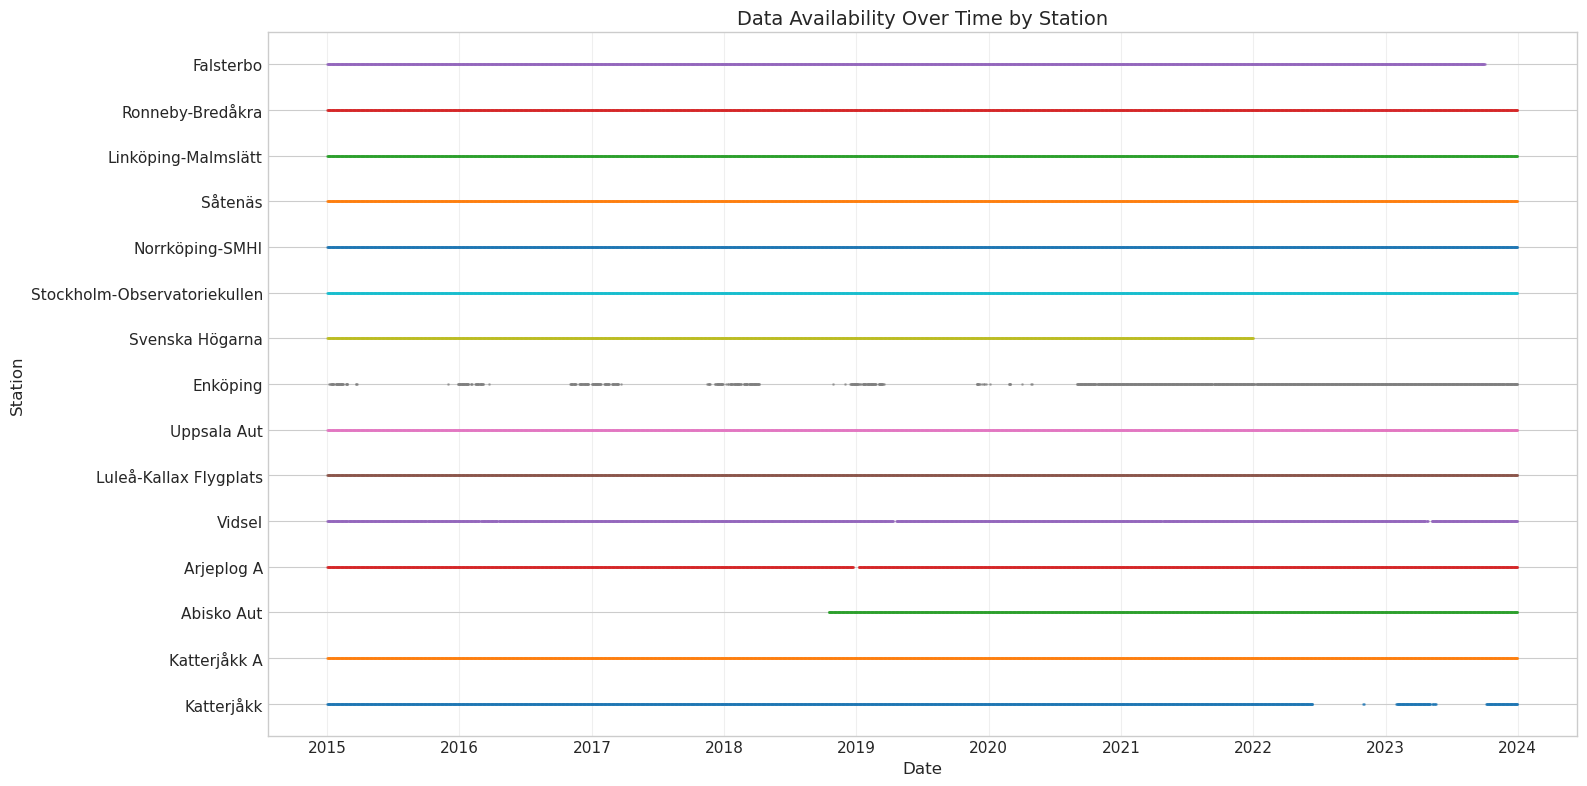

In [27]:
# Temporal data gaps visualization
fig, ax = plt.subplots(figsize=(16, 8))

station_order = stations.sort_values('Lat', ascending=False)['Name'].tolist()

for i, station in enumerate(station_order):
    station_df = df[df['station_name'] == station]
    ax.scatter(station_df['date'], [i] * len(station_df), s=1, alpha=0.5)

ax.set_yticks(range(len(station_order)))
ax.set_yticklabels(station_order)
ax.set_xlabel('Date')
ax.set_ylabel('Station')
ax.set_title('Data Availability Over Time by Station')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

---
## 10. Summary and Recommendations

In [28]:
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print(f"\n1. DATASET OVERVIEW:")
print(f"   - Total records: {len(df):,}")
print(f"   - Stations: {df['station_name'].nunique()}")
print(f"   - Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"   - Geographic span: {df['latitude'].min():.1f}°N to {df['latitude'].max():.1f}°N")

print(f"\n2. PARAMETER AVAILABILITY:")
for col in param_cols:
    coverage = df[col].notna().mean() * 100
    status = "GOOD" if coverage >= 70 else "FAIR" if coverage >= 40 else "LOW" if coverage > 0 else "NONE"
    print(f"   {col:15}: {coverage:5.1f}% [{status}]")

print(f"\n3. KEY FINDINGS:")
print(f"   - Wind (82%), Pressure (74%), Dew Point (74%) have excellent coverage")
print(f"   - Snow (59%), Cloud Cover (63%), Ground State (56%) have good coverage")
print(f"   - Humidity (30%), Precipitation (26%) have lower but usable coverage")
print(f"   - Temperature parameters (temp, temp_min, temp_max) are NOT available")
print(f"   - Dew point can serve as a temperature proxy")

print(f"\n4. RECOMMENDATIONS FOR MODEL TRAINING:")
print(f"   - Use: snow, wind, pressure, dew_point, cloud_cover as primary features")
print(f"   - Consider: humidity, precip, ground_state as secondary features")
print(f"   - Handle missing values with imputation or masking")
print(f"   - Consider downloading temperature separately (Parameter ID 2)")

print(f"\n5. MODEL INPUT FEATURES (AVAILABLE):")
available = ['snow', 'wind', 'pressure', 'dew_point', 'cloud_cover', 'humidity', 'precip', 'ground_state']
available = [f for f in available if f in cols_with_data]
print(f"   {available}")
print(f"   Plus: latitude, longitude, elevation, day_of_year (computed)")

FINAL SUMMARY

1. DATASET OVERVIEW:
   - Total records: 44,981
   - Stations: 15
   - Date range: 2015-01-01 to 2023-12-31
   - Geographic span: 55.4°N to 68.4°N

2. PARAMETER AVAILABILITY:
   snow           :  58.7% [FAIR]
   temp           :   0.0% [NONE]
   temp_min       :   0.0% [NONE]
   temp_max       :   0.0% [NONE]
   precip         :  25.5% [LOW]
   wind           :  82.3% [GOOD]
   humidity       :  30.1% [LOW]
   pressure       :  73.6% [GOOD]
   dew_point      :  73.5% [GOOD]
   cloud_cover    :  63.1% [FAIR]
   ground_state   :  55.6% [FAIR]

3. KEY FINDINGS:
   - Wind (82%), Pressure (74%), Dew Point (74%) have excellent coverage
   - Snow (59%), Cloud Cover (63%), Ground State (56%) have good coverage
   - Humidity (30%), Precipitation (26%) have lower but usable coverage
   - Temperature parameters (temp, temp_min, temp_max) are NOT available
   - Dew point can serve as a temperature proxy

4. RECOMMENDATIONS FOR MODEL TRAINING:
   - Use: snow, wind, pressure, dew_poin

In [29]:
# Save processed summary
summary = {
    'parameter': param_cols,
    'non_null': [df[c].notna().sum() for c in param_cols],
    'coverage_pct': [df[c].notna().mean() * 100 for c in param_cols],
    'mean': [df[c].mean() if df[c].notna().sum() > 0 else np.nan for c in param_cols],
    'std': [df[c].std() if df[c].notna().sum() > 0 else np.nan for c in param_cols],
    'min': [df[c].min() if df[c].notna().sum() > 0 else np.nan for c in param_cols],
    'max': [df[c].max() if df[c].notna().sum() > 0 else np.nan for c in param_cols],
}
summary_df = pd.DataFrame(summary)
summary_df.to_csv('../data/raw/smhi_metro_summary.csv', index=False)
print("\nSummary saved to: ../data/raw/smhi_metro_summary.csv")
display(summary_df)


Summary saved to: ../data/raw/smhi_metro_summary.csv


,parameter,non_null,coverage_pct,mean,std,min,max
0,snow,26416,58.727,0.118,0.321,-0.020,2.290
1,temp,0,0.000,NaN,NaN,NaN,NaN
2,temp_min,0,0.000,NaN,NaN,NaN,NaN
3,temp_max,0,0.000,NaN,NaN,NaN,NaN
4,precip,11480,25.522,1.623,3.747,-0.200,76.300
5,wind,37032,82.328,3.769,2.485,0.000,20.600
6,humidity,13518,30.053,4.834,1.718,-1.000,9.000
7,pressure,33125,73.642,1011.700,11.740,947.975,1053.900
8,dew_point,33070,73.520,2.299,8.185,-37.750,21.346
9,cloud_cover,28397,63.131,60.511,31.977,0.000,113.000


---
## Next Steps

1. **Download temperature data**: Run separate download for parameter 2 (daily mean temp) to add to dataset
2. **Data preprocessing**: Create pipeline to handle missing values and normalize features
3. **Feature engineering**: Add cyclical time features (day_sin, day_cos), lag features
4. **Train/Val/Test split**: Split by year (2015-2021 train, 2022 val, 2023 test)
5. **Model training**: Start with multi-task model using available features